<a href="https://colab.research.google.com/github/soumyadeep-mondal-dev/DMV_LAB/blob/main/company_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/company_dataset.csv')
display(df.head())

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees
0,0,TCS,3.8,(59.9k Reviews),Public,55 years old,"Mumbai,Maharashtra + 276 more",1 Lakh+ Employees (India)
1,1,Accenture,4.1,(38.3k Reviews),Public,34 years old,Dublin + 139 more,1 Lakh+ Employees (India)
2,2,Cognizant,3.9,(34.9k Reviews),Private,29 years old,Teaneck. New Jersey. + 109 more,1 Lakh+ Employees (India)
3,3,ICICI Bank,4.0,(28.5k Reviews),Public,29 years old,"Mumbai,Maharashtra + 1159 more",1 Lakh+ Employees (India)
4,4,Wipro,3.9,(28.4k Reviews),Public,78 years old,"Bangalore/Bengaluru,Karnataka + 235 more",1 Lakh+ Employees (India)


In [ ]:
employee_counts = df['employees'].value_counts()
display(employee_counts)

,count
employees,
1 Lakh+ Employees (India),14
10k-50k Employees (India),9
50k-1 Lakh Employees (India),5
1k-5k Employees (India),1


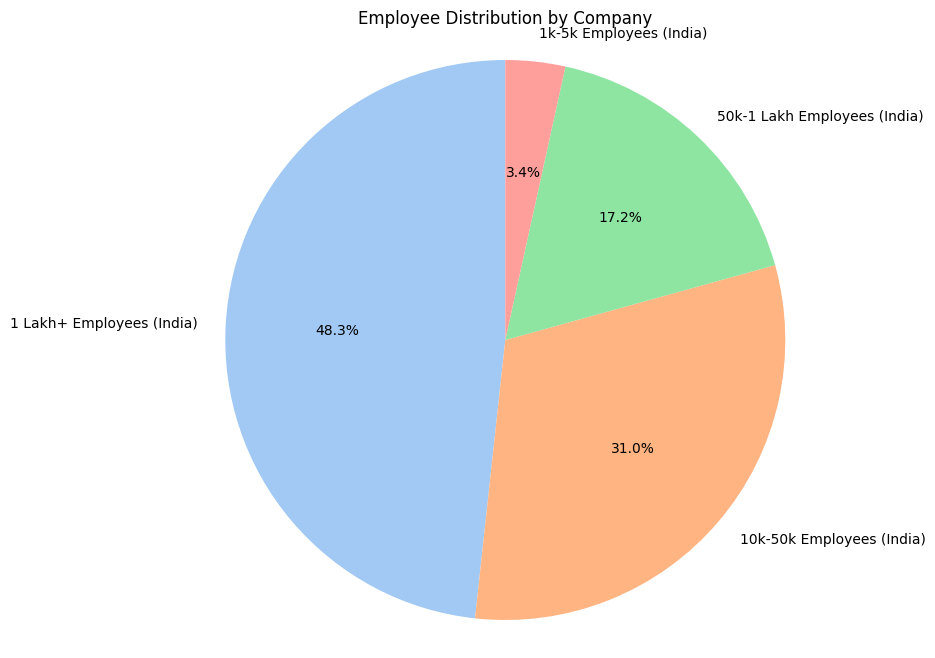

In [ ]:
fig = plt.figure(figsize=(10, 8))
plt.pie(employee_counts, labels=employee_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Employee Distribution by Company')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
import re

def parse_review_count(review_str):
    if isinstance(review_str, str):
        clean_str = review_str.replace('(', '').replace(' Reviews)', '').strip()
        if 'k' in clean_str:
            return float(clean_str.replace('k', '')) * 1000
        else:
            return float(clean_str)
    return None

df['parsed_review_count'] = df['review_count'].apply(parse_review_count)

# Define bins for review counts. Adjust as needed based on data distribution.
max_reviews = df['parsed_review_count'].max()
bins = [0, 10000, 20000, 30000, 40000, 50000, max_reviews + 1]
labels = ['0-10k', '10k-20k', '20k-30k', '30k-40k', '40k-50k', '50k+']

# Categorize companies into review count bins
df['review_count_category'] = pd.cut(df['parsed_review_count'], bins=bins, labels=labels, right=False)

# Count companies in each category
review_category_counts = df['review_count_category'].value_counts().sort_index()

display(review_category_counts)

,count
review_count_category,
0-10k,4
10k-20k,15
20k-30k,8
30k-40k,2
40k-50k,0
50k+,1


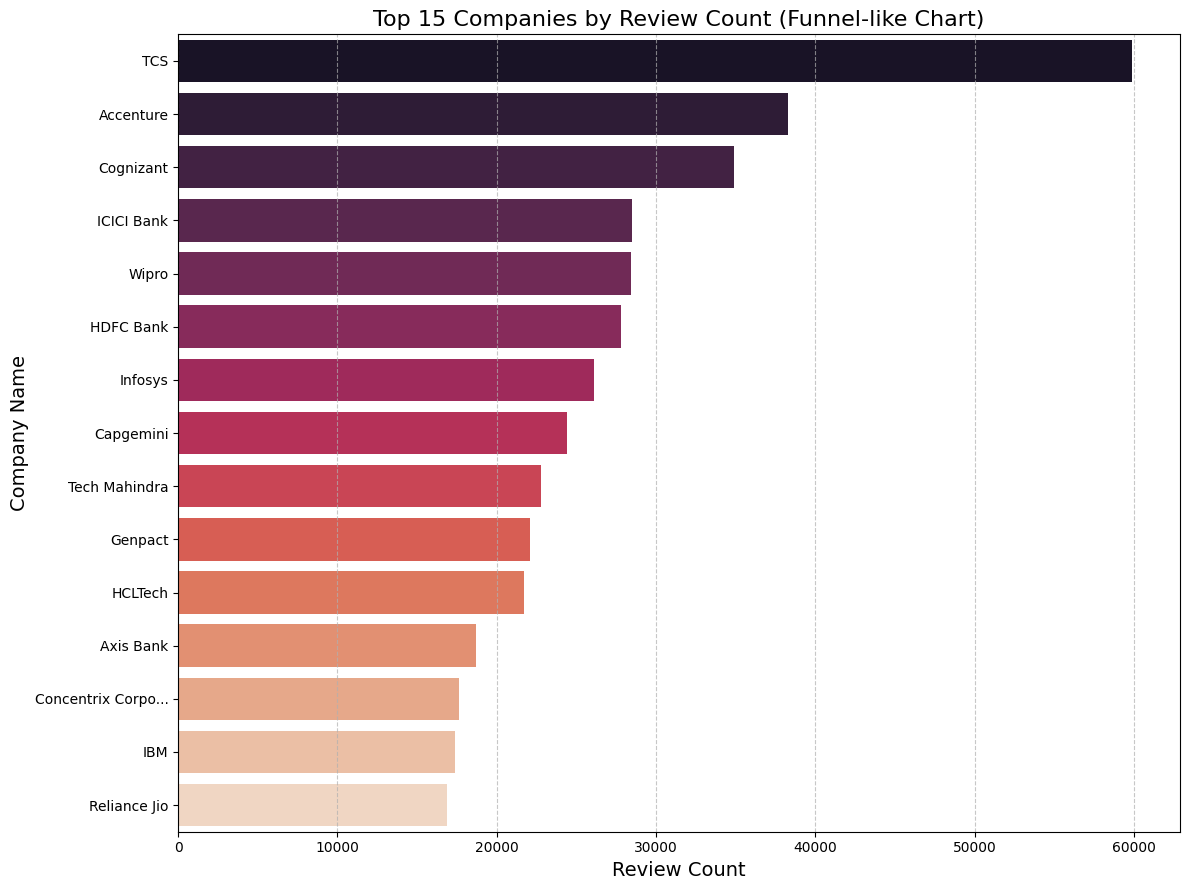

In [ ]:
# Sort companies by parsed review count in descending order
df_sorted_by_reviews = df.sort_values(by='parsed_review_count', ascending=False)

# Select the top N companies for better readability in the chart
# Let's choose the top 15 companies for this visualization
top_n = 15
top_companies_by_reviews = df_sorted_by_reviews.head(top_n)

fig, ax = plt.subplots(figsize=(12, 9))

sns.barplot(x='parsed_review_count', y='name', hue='name', data=top_companies_by_reviews, palette='rocket', ax=ax, legend=False)

ax.set_title(f'Top {top_n} Companies by Review Count (Funnel-like Chart)', fontsize=16)
ax.set_xlabel('Review Count', fontsize=14)
ax.set_ylabel('Company Name', fontsize=14)
ax.ticklabel_format(style='plain', axis='x') # Prevent scientific notation on x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
company_headquarters = df[['name', 'hq']].drop_duplicates().head(10)
display(company_headquarters)

,name,hq
0,TCS,"Mumbai,Maharashtra + 276 more"
1,Accenture,Dublin + 139 more
2,Cognizant,Teaneck. New Jersey. + 109 more
3,ICICI Bank,"Mumbai,Maharashtra + 1159 more"
4,Wipro,"Bangalore/Bengaluru,Karnataka + 235 more"
5,HDFC Bank,"Mumbai,Maharashtra + 1390 more"
6,Infosys,"Bengaluru/Bangalore,Karnataka + 132 more"
7,Capgemini,Paris + 81 more
8,Tech Mahindra,"Pune,Maharashtra + 221 more"
9,Genpact,"New York,New York + 76 more"


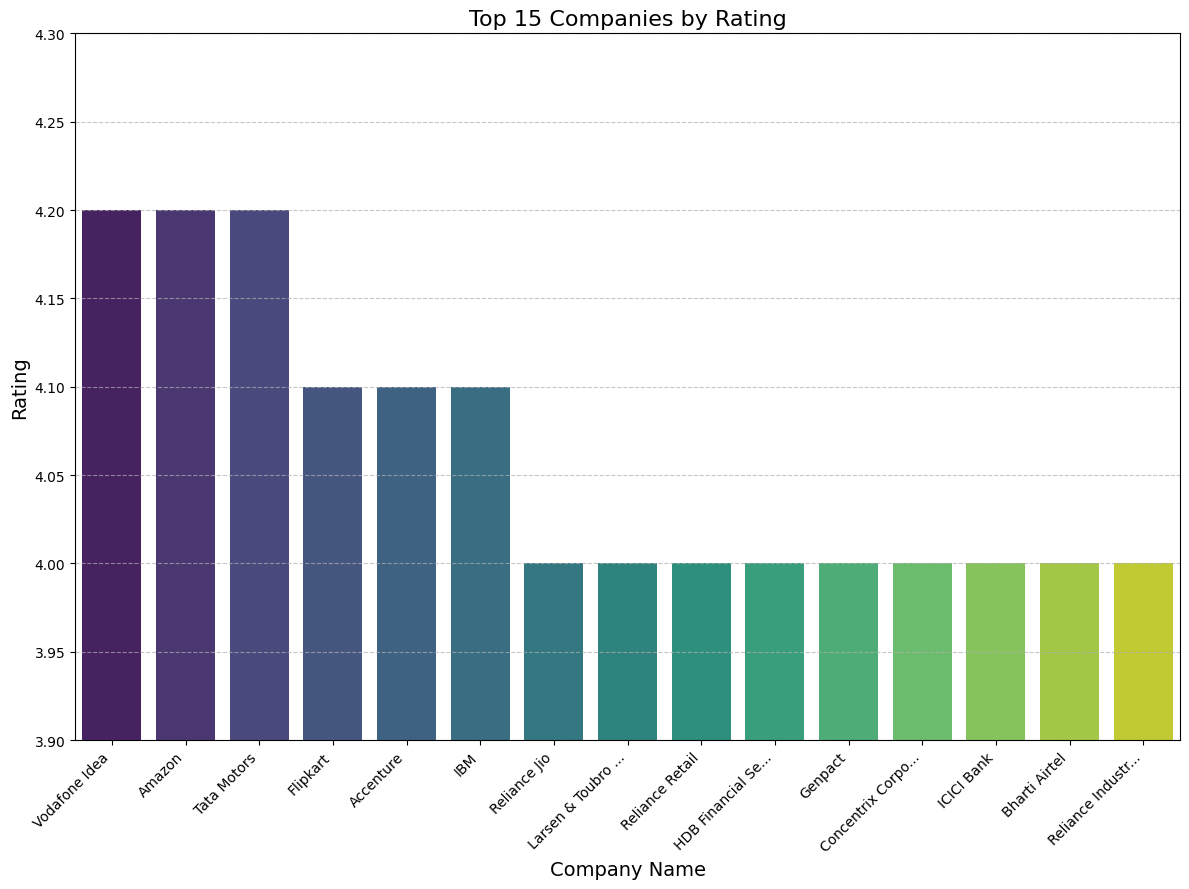

In [ ]:
# Sort companies by ratings in descending order
df_sorted_by_ratings = df.sort_values(by='ratings', ascending=False)

# Select the top N companies for visualization
top_n_ratings = 15
top_companies_by_ratings = df_sorted_by_ratings.head(top_n_ratings)

fig, ax = plt.subplots(figsize=(12, 9))

sns.barplot(x='name', y='ratings', hue='name', data=top_companies_by_ratings, palette='viridis', ax=ax, legend=False)

ax.set_title(f'Top {top_n_ratings} Companies by Rating', fontsize=16)
ax.set_xlabel('Company Name', fontsize=14)
ax.set_ylabel('Rating', fontsize=14)
plt.ylim(top_companies_by_ratings['ratings'].min() - 0.1, top_companies_by_ratings['ratings'].max() + 0.1) # Adjust y-axis limits for better visualization
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
import plotly.express as px
import pandas as pd

funnel_df = df[['name', 'review_count']].copy()

def clean_reviews(val):
    if pd.isna(val): return 0
    val = str(val).lower().replace('reviews', '').replace('(', '').replace(')', '').replace(',', '').strip()
    if 'k' in val:
        return float(val.replace('k', '')) * 1000
    try:
        return float(val)
    except:
        return 0

funnel_df['review_val'] = funnel_df['review_count'].apply(clean_reviews)

# Sort values for the funnel
funnel_df = funnel_df.sort_values(by='review_val', ascending=False)

fig = px.funnel(funnel_df, x='review_val', y='name',
                title='Companies Funnel by Review Count',
                labels={'review_val': 'Number of Reviews', 'name': 'Company Name'})
fig.show()

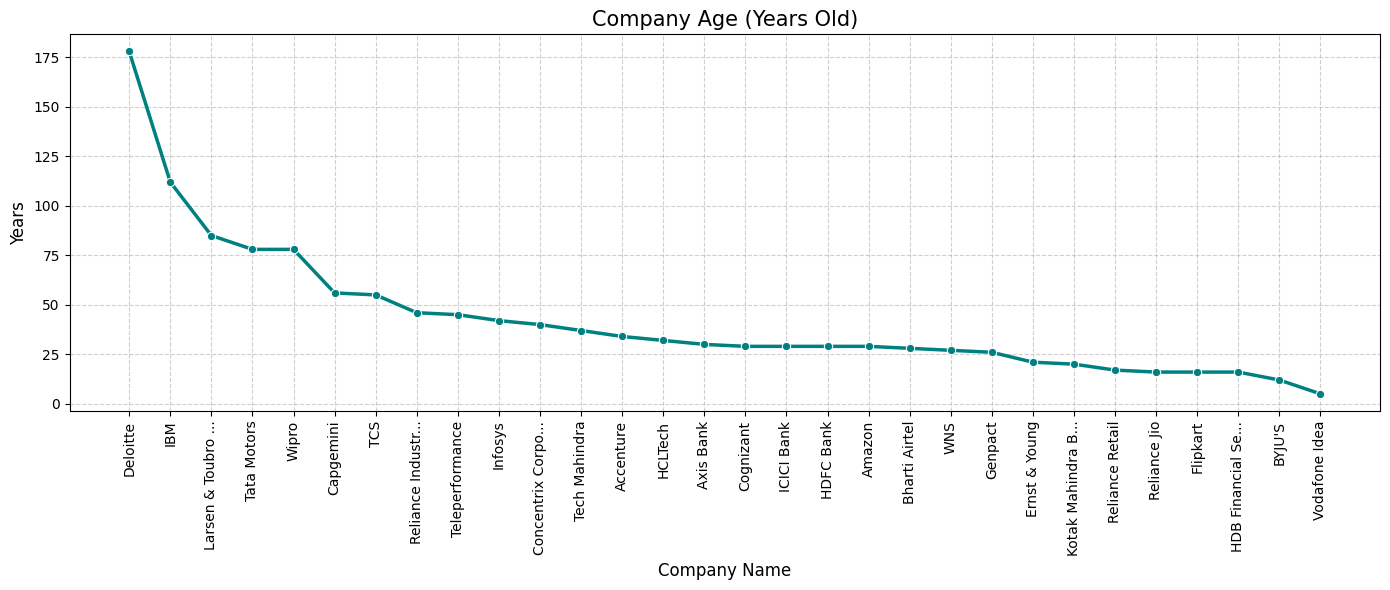

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to extract numeric years
def extract_years(year_str):
    if pd.isna(year_str): return 0
    try:
        # Extract the first number found in the string
        return int(str(year_str).split()[0])
    except (ValueError, IndexError):
        return 0

# Prepare data
df['years_numeric'] = df['years'].apply(extract_years)
age_df = df[['name', 'years_numeric']].sort_values(by='years_numeric', ascending=False)

# Create Line Chart
plt.figure(figsize=(14, 6))
sns.lineplot(x='name', y='years_numeric', data=age_df, marker='o', color='teal', linewidth=2.5)

# Formatting
plt.title('Company Age (Years Old)', fontsize=15)
plt.xlabel('Company Name', fontsize=12)
plt.ylabel('Years', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()